In [1]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Configuration du notebook
EXTRA_COLS  = ['clim_precip', 'clim_temp']
IN_CHANNELS = 12
MODEL_NAME  = 'model_arkansas_climate'

In [3]:
class CNNSubmodule(nn.Module):
    def __init__(self, in_channels=10):
        super(CNNSubmodule, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, in_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(in_channels)
        self.conv2 = nn.Conv1d(in_channels, in_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(in_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.transpose(1, 2)
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + identity
        out = self.relu(out)
        return out.transpose(1, 2)


class ALPE(nn.Module):
    def __init__(self, d_model=10, max_len=36):
        super(ALPE, self).__init__()
        self.d_model = d_model
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:d_model//2])
        self.register_buffer('pe', pe.unsqueeze(0))
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.eca_conv = nn.Conv1d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def eca(self, x):
        y = self.avg_pool(x)
        y = self.eca_conv(y.transpose(-1, -2)).transpose(-1, -2)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

    def forward(self, x, input2_mask):
        b, t, c = x.size()
        pos_vector = self.pe[:, :t, :].clone().repeat(b, 1, 1)
        pos_vector = pos_vector * input2_mask
        pos_vector = pos_vector.transpose(1, 2)
        pos_vector = self.conv1d(pos_vector)
        pos_vector = self.eca(pos_vector)
        return pos_vector.transpose(1, 2)


class TransformerSubmodule(nn.Module):
    def __init__(self, d_model=10, nhead=None, dim_feedforward=64, use_alpe=False):
        super(TransformerSubmodule, self).__init__()
        self.use_alpe = use_alpe
        if nhead is None:
            for n in [5, 4, 3, 2, 1]:
                if d_model % n == 0:
                    nhead = n
                    break
        if self.use_alpe:
            self.alpe = ALPE(d_model=d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)

    def forward(self, x, input2_mask=None):
        if self.use_alpe and input2_mask is not None:
            pos_info = self.alpe(x, input2_mask)
            x = x + pos_info
        out = self.transformer_encoder(x)
        return out


class MCTNet(nn.Module):
    def __init__(self, num_classes, in_channels=10):
        super(MCTNet, self).__init__()
        c1 = in_channels
        c2 = in_channels * 2
        c3 = in_channels * 4
        out_features = in_channels * 8
        self.cnn1 = CNNSubmodule(in_channels=c1)
        self.trans1 = TransformerSubmodule(d_model=c1, use_alpe=True)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.cnn2 = CNNSubmodule(in_channels=c2)
        self.trans2 = TransformerSubmodule(d_model=c2, use_alpe=False)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.cnn3 = CNNSubmodule(in_channels=c3)
        self.trans3 = TransformerSubmodule(d_model=c3, use_alpe=False)
        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.mlp = nn.Sequential(
            nn.Linear(out_features, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, mask):
        c1 = self.cnn1(x)
        t1 = self.trans1(x, mask)
        x = torch.cat([c1, t1], dim=-1)
        x = self.pool1(x.transpose(1, 2)).transpose(1, 2)
        c2 = self.cnn2(x)
        t2 = self.trans2(x)
        x = torch.cat([c2, t2], dim=-1)
        x = self.pool2(x.transpose(1, 2)).transpose(1, 2)
        c3 = self.cnn3(x)
        t3 = self.trans3(x)
        x = torch.cat([c3, t3], dim=-1)
        x = self.global_pool(x.transpose(1, 2)).squeeze(-1)
        return self.mlp(x)

In [4]:
df_ark = pd.read_csv('../data/arkansas_preprocessed_v2.csv')
df_ark.head()

,d0_B2,d0_B3,d0_B4,d0_B5,d0_B6,d0_B7,d0_B8,d0_B8A,d0_B11,d0_B12,...,d35_B8A,d35_B11,d35_B12,clim_precip,clim_temp,soil_texture,topo_elevation,topo_slope,cropland,target_class
0,0.0505,0.0758,0.10135,0.12890,0.1361,0.14435,0.16065,0.15805,0.11945,0.07645,...,0.19435,0.1425,0.09335,-1.852316,-2.559609,0.545543,0.527846,-0.696317,3,2
1,0.0645,0.0857,0.11530,0.13840,0.1542,0.16320,0.18710,0.18750,0.25540,0.19040,...,0.24080,0.2744,0.18450,-0.435476,-0.189180,0.545543,0.067849,-0.696317,2,1
2,0.0867,0.1072,0.14110,0.15910,0.1697,0.18090,0.20630,0.20340,0.22120,0.15450,...,0.20600,0.2376,0.17190,-0.874820,-0.424767,0.545543,0.251848,-1.295287,1,0
3,0.0631,0.0884,0.11200,0.14830,0.1979,0.21770,0.24190,0.23800,0.24200,0.17210,...,0.24190,0.3148,0.24250,0.735092,1.232434,0.545543,-1.036141,0.500368,2,1
4,0.0590,0.0772,0.09770,0.11405,0.1153,0.12705,0.13900,0.13425,0.13860,0.08885,...,0.09675,0.1053,0.06840,-0.436471,-0.184275,-1.790829,0.113849,-1.295287,1,0


In [5]:
mapping_ark = {1: 0, 2: 1, 3: 2, 5: 3}
def map_classes_ark(val):
    return mapping_ark.get(val, 4)

df_ark['target_class'] = df_ark['cropland'].apply(map_classes_ark)

targets_ark = {0: 4677, 1: 762, 2: 2423, 3: 1522, 4: 616}
sampled_dfs = []
for class_id, count in targets_ark.items():
    sub_df = df_ark[df_ark['target_class'] == class_id]
    sampled_dfs.append(sub_df.sample(n=min(len(sub_df), count), random_state=42))

df_ark_final = pd.concat(sampled_dfs).sample(frac=1, random_state=42)
print(df_ark_final['target_class'].value_counts())

target_class
0    4677
2    2423
3    1522
1     762
4     616
Name: count, dtype: int64


In [6]:
def prepare_mctnet_data(df, extra_cols=None):
    BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    ordered_cols = [f'd{i}_{band}' for i in range(36) for band in BANDS]
    x_spectral = torch.tensor(df[ordered_cols].values, dtype=torch.float32).view(-1, 36, 10)
    if extra_cols and len(extra_cols) > 0:
        x_extra = torch.tensor(df[extra_cols].values, dtype=torch.float32)
        x_extra_expanded = x_extra.unsqueeze(1).expand(-1, 36, -1)
        x_final = torch.cat([x_spectral, x_extra_expanded], dim=-1)
    else:
        x_final = x_spectral
    mask = (x_spectral > 0).all(dim=-1, keepdim=True).float()
    y = torch.tensor(df['target_class'].values, dtype=torch.long)
    return x_final, mask, y

x_ark, mask_ark, y_ark = prepare_mctnet_data(df_ark_final, extra_cols=EXTRA_COLS)
print(f'Shape X: {x_ark.shape}, Mask: {mask_ark.shape}, Y: {y_ark.shape}')

Shape X: torch.Size([10000, 36, 12]), Mask: torch.Size([10000, 36, 1]), Y: torch.Size([10000])


In [7]:
x_train, x_temp, m_train, m_temp, y_train, y_temp = train_test_split(
    x_ark, mask_ark, y_ark, test_size=0.18, stratify=y_ark, random_state=42
)
x_val, x_test, m_val, m_test, y_val, y_test = train_test_split(
    x_temp, m_temp, y_temp, test_size=0.8, stratify=y_temp, random_state=42
)

train_loader = DataLoader(TensorDataset(x_train, m_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val,   m_val,   y_val),   batch_size=64)
test_loader  = DataLoader(TensorDataset(x_test,  m_test,  y_test),  batch_size=64)

print(f'Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}')

Train=8200, Val=360, Test=1440


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 20
best_f1 = 0.0
print(f'Device utilisé : {device}')

model = MCTNet(num_classes=5, in_channels=IN_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = torch.nn.CrossEntropyLoss()
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f'Époque {epoch+1}/{epochs}', unit='batch')
    for b_x, b_mask, b_y in pbar:
        b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
        optimizer.zero_grad()
        outputs = model(b_x, b_mask)
        loss = criterion(outputs, b_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0
    with torch.no_grad():
        for b_x, b_mask, b_y in val_loader:
            b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
            outputs = model(b_x, b_mask)
            val_loss += criterion(outputs, b_y).item()
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(b_y.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(
        val_targets, val_preds, average='macro', zero_division=0
    )
    val_acc = 100 * np.sum(np.array(val_preds) == np.array(val_targets)) / len(val_targets)
    print(f'\n[Validation] Loss: {val_loss/len(val_loader):.4f} | Acc: {val_acc:.2f}%')
    print(f'[Scores] Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}\n')

    if f1 > best_f1:
        best_f1 = f1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f'Meilleur modèle mis à jour (F1: {best_f1:.4f})')

model.load_state_dict(best_model_state)
print(f'\nEntraînement fini. Meilleur F1: {best_f1:.4f}')

Device utilisé : cuda


Époque 1/20: 100%|██████████| 129/129 [00:02<00:00, 50.37batch/s, loss=1.0052]



[Validation] Loss: 1.0246 | Acc: 55.28%
[Scores] Precision: 0.5342 | Recall: 0.3611 | F1-Score: 0.3664

Meilleur modèle mis à jour (F1: 0.3664)


Époque 2/20: 100%|██████████| 129/129 [00:02<00:00, 47.63batch/s, loss=0.5685]



[Validation] Loss: 0.6938 | Acc: 77.22%
[Scores] Precision: 0.7510 | Recall: 0.7132 | F1-Score: 0.7170

Meilleur modèle mis à jour (F1: 0.7170)


...


[Validation] Loss: 0.2315 | Acc: 91.39%
[Scores] Precision: 0.9053 | Recall: 0.9112 | F1-Score: 0.9068



Époque 19/20: 100%|██████████| 129/129 [00:01<00:00, 88.44batch/s, loss=0.2193]



[Validation] Loss: 0.2188 | Acc: 92.50%
[Scores] Precision: 0.9104 | Recall: 0.9218 | F1-Score: 0.9151



Époque 20/20: 100%|██████████| 129/129 [00:01<00:00, 88.80batch/s, loss=0.3068]



[Validation] Loss: 0.2161 | Acc: 91.94%
[Scores] Precision: 0.9112 | Recall: 0.9158 | F1-Score: 0.9120


Entraînement fini. Meilleur F1: 0.9157


In [9]:
torch.save(model.state_dict(), f'models_ark/model_arkansas_climate.pth')
print('Modèle sauvegardé : model_arkansas_climate.pth')

Modèle sauvegardé : model_arkansas_climate.pth


=== Arkansas — model_arkansas_climate ===
OA    : 0.9299
Kappa : 0.8985
              precision    recall  f1-score   support

    Soybeans       0.96      0.95      0.96       673
      Cotton       0.95      0.91      0.93       110
        Rice       0.94      0.94      0.94       349
        Corn       0.84      0.85      0.85       219
      Others       0.87      0.93      0.90        89

    accuracy                           0.93      1440
   macro avg       0.91      0.92      0.92      1440
weighted avg       0.93      0.93      0.93      1440



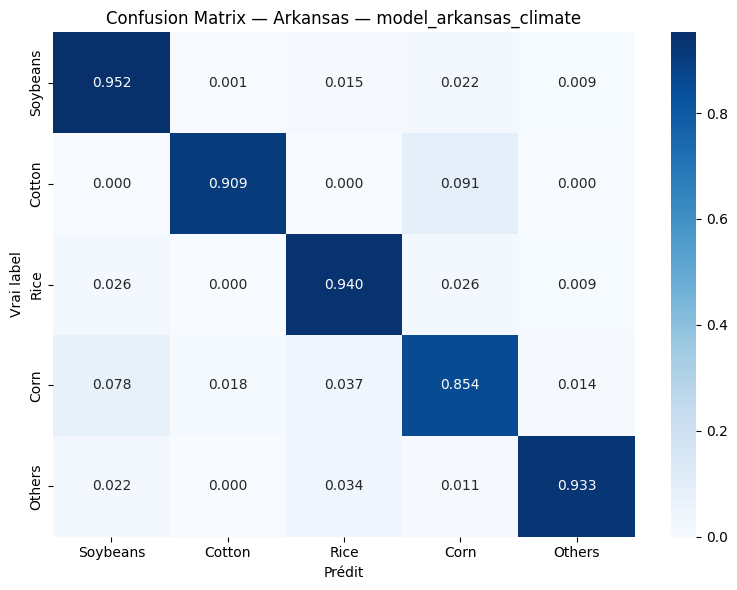

In [10]:
classes_ar = ['Soybeans', 'Cotton', 'Rice', 'Corn', 'Others']

def evaluate_on_test(model, test_loader, class_names, title):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for b_x, b_mask, b_y in test_loader:
            b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
            outputs = model(b_x, b_mask)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(b_y.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    oa    = (all_preds == all_labels).mean()
    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f'=== {title} ===')
    print(f'OA    : {oa:.4f}')
    print(f'Kappa : {kappa:.4f}')
    print(classification_report(all_labels, all_preds, target_names=class_names))
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.3f', xticklabels=class_names,
                yticklabels=class_names, cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.savefig(f'./figs/{MODEL_NAME}_confusion_matrix.png', dpi=150)
    plt.show()

evaluate_on_test(model, test_loader, classes_ar, 'Arkansas — model_arkansas_climate')